# Description


The aim of these codes is to replicate the **Global Optimisation Test** that have been carried out in the paper. In this paper an inversion-problem is solved by minimizing a particular misift function via Simulated Annealing to find the petro-physical parameters that produce the **measurments of seismic waves and the electrical conductivity**.


The Global Optimization Test is used to:

1. **Calibrate the Simulated Annealing optimization algorithm**

2. **Determine the optimal weighting between seismic and electrical data**

3. **Estimate the expected error of the petrophysical parameters**

4. **Analyze the sensitivity of the inversion to the different parameters**


In my project I tried to replicate the Global Optimisation Test with **Simulated Annealing(SA)** and try two other optimisation algorithms, **PSO** and **CMA-ES**.

In these first part of the project i wanted to do a preliminary test of the algorithms for the optimisation to set a base case and try to follow the workflow used also in the paper with PSO and CMA-ES. 
The hyper-parameter of SA that I used are the same of the ones used by the paper except that the temperature initial value that changed from $T_0 = 1e^{-6}$ to $T_0 = 1e^{-4}$ because with that schedule i was obtaining better results.
In the paper a geometric schedule for temperature has been used an so i kept that schedule.

The main Workflow of the code is the follow one:

0. **Parameter setup and compilation with Numba**

1. **For loop over *k* to set the clay content $C$**
   
   1.1 **Definition of the true model**  
   1.2 **Generation of the true measurements using forward modelling**  
   1.3 **Generation of noisy measurements by adding Gaussian noise**  
   1.4 **First inversion, compute the errors and print of the results**  
   1.5 **Restriction of the search interval on the parameter $\xi$**  
   1.6 **Second inversion, compute the errors and print of the results**
2. **For each parameter take the average over the varying $C$'s values of the errors after the second inversion**
3. **Plot of the results**


The choice of always starting at the midpoint of the searching intervals of the parameters, cause the second inversion to be independent from the first inversion. This choice has been made by the authors of the paper and so I kept it.
The restriction of the searching interval for parameter $\xi$ is made to show how the ability to be able to restrict the search intervals of some parameters by the knowldge of physical priors can influence the performance of the optimisation.

The hyper-parameters, as the number of iterations or the number of particles, have been choosen among the algorithms in order to have almost the same number of evaluations of the fitness/misfit

# SA


RUN k = 0
TRUE:
  Vp_true    = 1332.04 m/s
  Vs_true    = 101.384 m/s
  sigma_true = 0.293161 S/m

OBS (1% noise):
  Vp_obs     = 1335.13 m/s
  Vs_obs     = 101.415 m/s
  sigma_obs  = 0.296745 S/m

=== Phase 1 SA inversion (start = mid bounds) ===
Best objective f = 9.106760e-10

Recovered parameters (v_best):
  phi_percent   = 39.495084
  C_percent     = 15.039610
  S_b_percent   = 97.588464
  sigma_b_inv   = 0.559326
  xi            = 2.872490

Deviations vs true_model first inversion:
  devPHI (pp)   = -1.5049
  devCC  (pp)   = 5.0396
  devSB  (pp)   = 7.5885
  devROb (%)    = 11.8652
  devfac (%)    = 6.3885

Absolute deviations first inversion:
  |devPHI| (pp) = 1.5049
  |devCC|  (pp) = 5.0396
  |devSB|  (pp) = 7.5885
  |devROb| (%)  = 11.8652
  |devfac| (%)  = 6.3885

=== Phase 2 SA inversion (restart = mid bounds, xi in [2.5, 2.9]) ===
Best objective f = 7.095355e-10

Recovered parameters after Phase 2 (v_best2):
  phi_percent   = 42.154201
  C_percent     = 5.150371
  S_b_perc

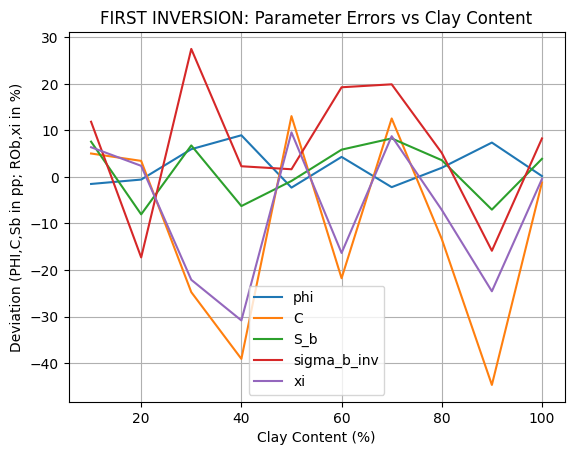

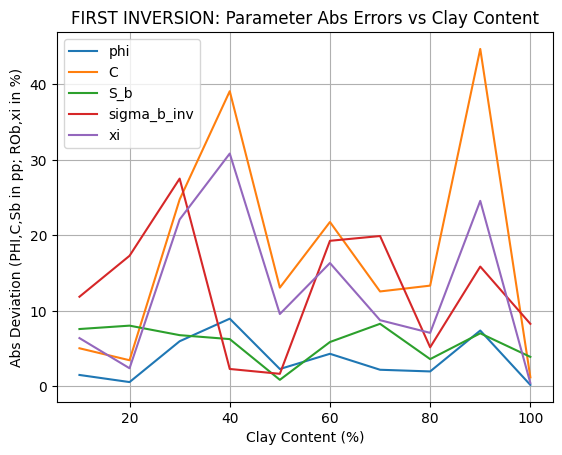

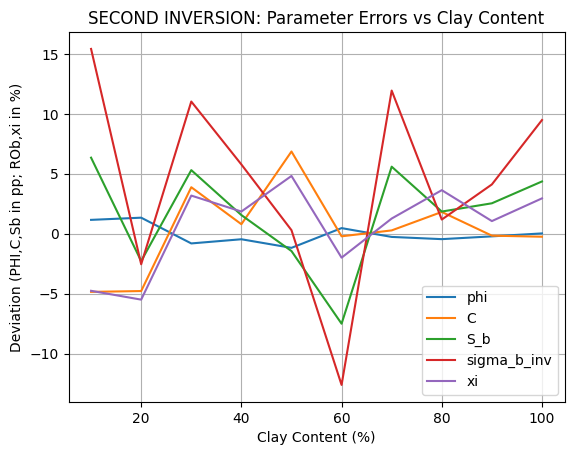

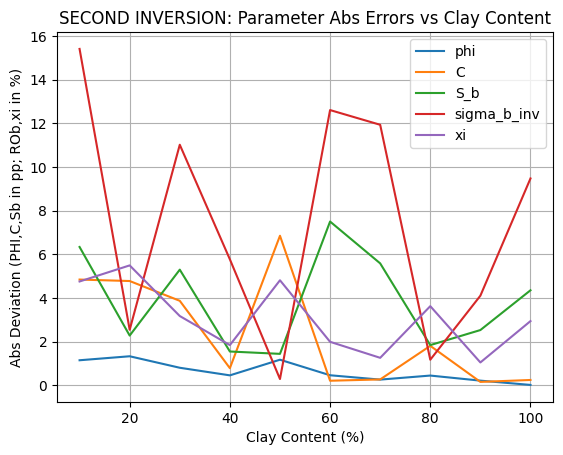

 aerr_phi2 average is = 0.6376029600437952
 aerr_C2 average is = 2.387651903847793
 aerr_Sb2 average is = 3.8769983395647687
 aerr_rhob2 average is = 7.4369393442476595
 aerr_xi2 average is = 3.0999998105428705


In [1]:
# ============================================================
# NUMBA-accelerated version 
# ============================================================

from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit
import os 

save_dir = os.path.expanduser("~/Units/Global and Multiobjective Optimization")
os.makedirs(save_dir, exist_ok=True)


#############################################################
# 1) Fixed physical parameters
#############################################################

@dataclass
class RockFluidConstants:
    # Quartz phase
    K_q: float = 37.3e9
    mu_q: float = 44.3e9
    rho_q: float = 2600.0
    sigma_q: float = 1e-6

    # Clay phase (second solid phase)
    K_c: float = 20.9e9
    mu_c: float = 6.9e9
    rho_c: float = 2650.0
    sigma_c: float = 0.1

    # Brine phase
    K_b: float = 2.25e9
    rho_b: float = 1030.0

    # Air phase
    K_a: float = 76e3
    rho_a: float = 1.2
    sigma_a: float = 1e-4


def const_to_array(c: RockFluidConstants) -> np.ndarray:
    return np.array(
        [
            c.K_q, c.mu_q, c.rho_q, c.sigma_q,
            c.K_c, c.mu_c, c.rho_c, c.sigma_c,
            c.K_b, c.rho_b,
            c.K_a, c.rho_a, c.sigma_a
        ],
        dtype=np.float64
    )


# constants array indices
K_q, mu_q, rho_q, sigma_q = 0, 1, 2, 3
K_c, mu_c, rho_c, sigma_c = 4, 5, 6, 7
K_b, rho_b = 8, 9
K_a, rho_a, sigma_a = 10, 11, 12


#############################################################
# 2) True model
#############################################################

@dataclass
class TrueModel:
    phi_percent: float
    C_percent: float
    S_b_percent: float
    sigma_b_inv: float
    xi: float


#############################################################
# 3) Forward Modelling
#############################################################

@njit(cache=True)
def compute_AK_Amu(C_percent: float):
    A_K = 0.025 * C_percent + 2.37
    A_mu = -0.003 * C_percent + 3.14
    return A_K, A_mu


@njit(cache=True)
def forward_model(phi_percent, C_percent, S_b_percent, sigma_b_inv, xi, const):
    eps = 1e-18

    phi = phi_percent / 100.0
    C = C_percent / 100.0
    S_b = S_b_percent / 100.0

    # brine conductivity from resistivity
    if abs(sigma_b_inv) < eps:
        return np.nan, np.nan, np.nan
    sigma_b = 1.0 / sigma_b_inv

    # --- Bulk density ---
    rho_s = (1.0 - C) * const[rho_q] + C * const[rho_c]
    rho_f = (1.0 - S_b) * const[rho_a] + S_b * const[rho_b]
    rho_bulk = (1.0 - phi) * rho_s + phi * rho_f
    if rho_bulk <= 0.0 or (not np.isfinite(rho_bulk)):
        return np.nan, np.nan, np.nan

    # --- HS/Voigt style averages ---
    beta_q = 1.0 - C
    beta_c = C

    K_V = beta_q * const[K_q] + beta_c * const[K_c]
    mu_V = beta_q * const[mu_q] + beta_c * const[mu_c]
    if abs(K_V) < eps or abs(mu_V) < eps:
        return np.nan, np.nan, np.nan

    # maxima/minima
    if const[K_q] >= const[K_c]:
        K_max = const[K_q]; K_min = const[K_c]
    else:
        K_max = const[K_c]; K_min = const[K_q]

    if const[mu_q] >= const[mu_c]:
        mu_max = const[mu_q]; mu_min = const[mu_c]
    else:
        mu_max = const[mu_c]; mu_min = const[mu_q]

    # Guard on differences used in HS
    dK = const[K_c] - const[K_q]
    dmu = const[mu_c] - const[mu_q]
    if abs(dK) < eps or abs(dmu) < eps:
        return np.nan, np.nan, np.nan

    # HS bulk
    denom_plus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_max)
    denom_minus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_min)
    if abs(denom_plus) < eps or abs(denom_minus) < eps:
        return np.nan, np.nan, np.nan

    K_HS_plus = const[K_q] + (1.0 - beta_q) / denom_plus
    K_HS_minus = const[K_q] + (1.0 - beta_q) / denom_minus
    K_HS = 0.5 * (K_HS_plus + K_HS_minus)

    # HS shear helper denominators
    denom_hq = (K_max + 2.0 * mu_max)
    denom_hc = (K_min + 2.0 * mu_min)
    if abs(denom_hq) < eps or abs(denom_hc) < eps:
        return np.nan, np.nan, np.nan

    hs_shear_q = const[mu_q] + (mu_max / 6.0) * ((9.0 * K_max + 8.0 * mu_max) / denom_hq)
    hs_shear_c = const[mu_q] + (mu_min / 6.0) * ((9.0 * K_min + 8.0 * mu_min) / denom_hc)

    denom_mu_plus = (1.0 / dmu) + beta_q / hs_shear_q
    denom_mu_minus = (1.0 / dmu) + beta_q / hs_shear_c
    if abs(denom_mu_plus) < eps or abs(denom_mu_minus) < eps:
        return np.nan, np.nan, np.nan

    mu_HS_plus = const[mu_q] + (1.0 - beta_q) / denom_mu_plus
    mu_HS_minus = const[mu_q] + (1.0 - beta_q) / denom_mu_minus
    mu_HS = 0.5 * (mu_HS_plus + mu_HS_minus)

    # --- Matrix moduli ---
    A_K, A_mu = compute_AK_Amu(C_percent)

    denom = 1.0 - phi
    if denom <= 1e-15:
        return np.nan, np.nan, np.nan

    exponent_bulk = A_K / denom
    exponent_shear = xi * A_mu / denom

    one_minus_phi = 1.0 - phi
    bulk_factor = one_minus_phi ** exponent_bulk
    shear_factor = one_minus_phi ** exponent_shear

    K_m_q = (K_HS / K_V) * beta_q * const[K_q] * bulk_factor
    K_m_c = (K_HS / K_V) * beta_c * const[K_c] * bulk_factor
    K_m = K_m_q + K_m_c

    mu_m_q = (mu_HS / mu_V) * beta_q * const[mu_q] * shear_factor
    mu_m_c = (mu_HS / mu_V) * beta_c * const[mu_c] * shear_factor
    mu_m = mu_m_q + mu_m_c

    # --- Fluid bulk modulus ---
    denom_Kf = (1.0 - S_b) / const[K_a] + S_b / const[K_b]
    if abs(denom_Kf) < eps:
        return np.nan, np.nan, np.nan
    K_f = 1.0 / denom_Kf

    # --- Gassmann ---
    alpha_q = beta_q - K_m_q / const[K_q]
    alpha_c = beta_c - K_m_c / const[K_c]

    phi_q_prime = alpha_q - beta_q * phi
    phi_c_prime = alpha_c - beta_c * phi

    M_inv = (phi_q_prime / const[K_q]) + (phi_c_prime / const[K_c]) + (phi / K_f)
    if (not np.isfinite(M_inv)) or abs(M_inv) < 1e-18:
        return np.nan, np.nan, np.nan

    M = 1.0 / M_inv
    K_G = K_m + (alpha_q + alpha_c) ** 2 * M
    mu_G = mu_m

    # Velocities
    Vp = math.sqrt((K_G + (4.0 / 3.0) * mu_G) / rho_bulk)
    Vs = math.sqrt(mu_G / rho_bulk)

    # --- Conductivity (CRIM) ---
    gamma = 0.5
    term_sigma = (
        (1.0 - phi) * (1.0 - C) * (const[sigma_q] ** gamma) +
        (1.0 - phi) * C * (const[sigma_c] ** gamma) +
        phi * S_b * (sigma_b ** gamma) +
        phi * (1.0 - S_b) * (const[sigma_a] ** gamma)
    )

    if (not np.isfinite(term_sigma)) or term_sigma <= 0.0:
        return np.nan, np.nan, np.nan

    sigma_bulk = term_sigma ** (1.0 / gamma)
    return Vp, Vs, sigma_bulk


#############################################################
# MISFIT
#############################################################


@njit(cache=True)
def objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2):
    if (not np.isfinite(Vp_T)) or (not np.isfinite(Vs_T)) \
       or (not np.isfinite(sigma_T)) or sigma_T <= 0.0:
        return 1e300

    Vp, Vs, sigma = forward_model(
        x[0], x[1], x[2], x[3], x[4], const
    )

    #Check the validity and assign bad fitness is not so
    if (not np.isfinite(Vp)) or (not np.isfinite(Vs)) \
       or (not np.isfinite(sigma)) or sigma <= 0.0:
        return 1e300

    return (
        abs(Vp - Vp_T)
        + W1 * abs(Vs - Vs_T)
        + W2 * abs((1.0 / sigma) - (1.0 / sigma_T))
    )


#############################################################
# Simulated Annealing
#############################################################

# Use Box-Muller to generate Gaussian random Number
@njit(cache=True)
def randn_box_muller():
    u1 = np.random.random()
    u2 = np.random.random()
    if u1 < 1e-16:
        u1 = 1e-16
    return math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)


# How to select a new point during SA iterations
@njit(cache=True)
def propose_neighbor(x, T, T0, lo, hi, step_frac):
    if T0 <= 0.0 or T <= 0.0:
        return x.copy()

    scale = math.sqrt(T / T0)
    y = x.copy()

    for j in range(5): #for every parameter
        span = hi[j] - lo[j]
        dx = randn_box_muller() * (step_frac * span * scale) #Standard deviation of perturbationd depends on T
        v = y[j] + dx
        # Clip the new point inside the searching interval
        if v < lo[j]:
            v = lo[j]
        elif v > hi[j]:
            v = hi[j]
        y[j] = v

    return y


@njit(cache=True)
def geometric_cooling_stepwise(T0, iteration, alpha, interval):
    k = (iteration - 1) // interval #define after how many iterations the temperature drops
    return T0 * (alpha ** k)


@njit(cache=True)
def simulated_annealing_single(
    Vp_T, Vs_T, sigma_T,
    const,
    lo, hi,
    step_frac,
    T0, W1, W2,
    tol,
    n_iters,
    warm_start,
    seed
):
    np.random.seed(seed)

    # Start exactly from warm_start 
    x = warm_start.copy()

    # Safety: clip to bounds (in case warm_start is slightly out)
    # useful if we change starting point from being deterministic to being sthocastic
    for j in range(5):
        if x[j] < lo[j]:
            x[j] = lo[j]
        elif x[j] > hi[j]:
            x[j] = hi[j]

    f = objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2)
    if not np.isfinite(f):
        f = 1e300

    best = x.copy()
    f_best = f

    alpha = 0.85
    cooling_interval = 2000

    for i in range(1, n_iters + 1):
        T = geometric_cooling_stepwise(T0, i, alpha, cooling_interval)

        cand = propose_neighbor(x, T, T0, lo, hi, step_frac)
        
        f_cand = objective(cand, Vp_T, Vs_T, sigma_T, const, W1, W2)
        
        if not np.isfinite(f_cand):
            f_cand = 1e300

        accept = False
        if f_cand < f:
            accept = True
        else:
            df = f_cand - f
            if np.isfinite(df) and T > 0.0:
                p = math.exp(-df / T)
                if np.random.random() < p:
                    accept = True

        if accept:
            x = cand
            f = f_cand
            if f < f_best:
                best = x.copy()
                f_best = f
                if f_best <= tol:
                    break

    return best, f_best


#############################################################
# 4) Utilities 
#############################################################

def add_relative_noise(rng: np.random.Generator, x: float, rel_std: float = 0.01) -> float:
    return x * (1.0 + rng.normal(0.0, rel_std))

def dev_points(out_percent: float, inp_percent: float) -> float:
    return out_percent - inp_percent

def dev_rel_percent(out: float, inp: float) -> float:
    eps = 1e-18
    denom = inp if abs(inp) > eps else eps
    return 100.0 * (out - inp) / denom

def midpoint_start(lo: np.ndarray, hi: np.ndarray) -> np.ndarray:
    return 0.5 * (lo + hi)


#############################################################
# 5) MAIN
#############################################################

if __name__ == "__main__":
    W1 = 1.0
    W2 = 100.0
    T0 = 1e4
    tol = 1e-9

    STEP_FRAC_PHASE1 = 0.5
    STEP_FRAC_PHASE2 = 0.1

    lo = np.array([0.0,   0.0,  80.0,  0.2, 1.0], dtype=np.float64)
    hi = np.array([70.0, 100.0, 100.0, 25.0, 3.0], dtype=np.float64)

    lo2 = lo.copy()
    hi2 = hi.copy()
    lo2[4] = 2.5
    hi2[4] = 2.9

    # ===========================
    # warm starts are midpoints 
    # ===========================
    warm_start_phase1 = midpoint_start(lo, hi).astype(np.float64)
    warm_start_phase2 = midpoint_start(lo2, hi2).astype(np.float64)

    const = const_to_array(RockFluidConstants())

    err_phi1, err_C1, err_Sb1, err_rhob1, err_xi1 = [], [], [], [], []
    aerr_phi1, aerr_C1, aerr_Sb1, aerr_rhob1, aerr_xi1 = [], [], [], [], []
    C_content1 = []

    err_phi2, err_C2, err_Sb2, err_rhob2, err_xi2 = [], [], [], [], []
    aerr_phi2, aerr_C2, aerr_Sb2, aerr_rhob2, aerr_xi2 = [], [], [], [], []
    C_content2 = []

    seed_noise = 369
    seed_run_phase1 = 123
    seed_run_phase2 = 246
    rng = np.random.default_rng(seed=seed_noise)

    # Warm-up compilation for Numba
    safe_x = np.array([41.0, 20.0, 90.0, 0.5, 2.7], dtype=np.float64)
    Vp_s, Vs_s, sig_s = forward_model(safe_x[0], safe_x[1], safe_x[2], safe_x[3], safe_x[4], const)
    _ = objective(safe_x, float(Vp_s), float(Vs_s), float(sig_s), const, W1, W2)
    _ = simulated_annealing_single(
        float(Vp_s), float(Vs_s), float(sig_s),
        const, lo, hi,
        STEP_FRAC_PHASE1,
        T0, W1, W2,
        tol,
        5,
        warm_start_phase1,   
        492
    )

    for k in range(0, 100, 10):
        print("\n" + "="*70)
        print(f"RUN k = {k}")
        print("="*70)

        true_model = TrueModel(
            phi_percent=41.0,
            C_percent=10.0 + k,
            S_b_percent=90.0,
            sigma_b_inv=0.5,
            xi=2.7
        )

        Vp_true, Vs_true, sigma_true = forward_model(
            true_model.phi_percent, true_model.C_percent, true_model.S_b_percent,
            true_model.sigma_b_inv, true_model.xi, const
        )

        Vp_obs = add_relative_noise(rng, float(Vp_true), 0.01)
        Vs_obs = add_relative_noise(rng, float(Vs_true), 0.01)
        sigma_obs = add_relative_noise(rng, float(sigma_true), 0.01)

        print("TRUE:")
        print(f"  Vp_true    = {Vp_true:.6g} m/s")
        print(f"  Vs_true    = {Vs_true:.6g} m/s")
        print(f"  sigma_true = {sigma_true:.6g} S/m")

        print("\nOBS (1% noise):")
        print(f"  Vp_obs     = {Vp_obs:.6g} m/s")
        print(f"  Vs_obs     = {Vs_obs:.6g} m/s")
        print(f"  sigma_obs  = {sigma_obs:.6g} S/m")

        # ===========================
        # Phase 1 starts from midpoint 
        # ===========================
        best1, f1 = simulated_annealing_single(
            Vp_obs, Vs_obs, sigma_obs,
            const, lo, hi,
            STEP_FRAC_PHASE1,
            T0, W1, W2,
            tol,
            1000_000,
            warm_start=warm_start_phase1, #always midpoint
            seed=seed_run_phase1 + k
        )

        print("\n=== Phase 1 SA inversion (start = mid bounds) ===")
        print(f"Best objective f = {f1:.6e}")
        print("\nRecovered parameters (v_best):")
        print(f"  phi_percent   = {best1[0]:.6f}")
        print(f"  C_percent     = {best1[1]:.6f}")
        print(f"  S_b_percent   = {best1[2]:.6f}")
        print(f"  sigma_b_inv   = {best1[3]:.6f}")
        print(f"  xi            = {best1[4]:.6f}")


        e_phi = dev_points(best1[0], true_model.phi_percent)
        e_C   = dev_points(best1[1], true_model.C_percent)
        e_Sb  = dev_points(best1[2], true_model.S_b_percent)
        e_rb  = dev_rel_percent(best1[3], true_model.sigma_b_inv)
        e_xi  = dev_rel_percent(best1[4], true_model.xi)

        ae_phi = abs(e_phi)
        ae_C   = abs(e_C)
        ae_Sb  = abs(e_Sb)
        ae_rb  = abs(e_rb)
        ae_xi  = abs(e_xi)



        print("\nDeviations vs true_model first inversion:")
        print(f"  devPHI (pp)   = {e_phi:.4f}")
        print(f"  devCC  (pp)   = {e_C:.4f}")
        print(f"  devSB  (pp)   = {e_Sb:.4f}")
        print(f"  devROb (%)    = {e_rb:.4f}")
        print(f"  devfac (%)    = {e_xi:.4f}")

        print("\nAbsolute deviations first inversion:")
        print(f"  |devPHI| (pp) = {ae_phi:.4f}")
        print(f"  |devCC|  (pp) = {ae_C:.4f}")
        print(f"  |devSB|  (pp) = {ae_Sb:.4f}")
        print(f"  |devROb| (%)  = {ae_rb:.4f}")
        print(f"  |devfac| (%)  = {ae_xi:.4f}")

        err_phi1.append(e_phi);   err_C1.append(e_C);     err_Sb1.append(e_Sb);    err_rhob1.append(e_rb);   err_xi1.append(e_xi)
        aerr_phi1.append(ae_phi); aerr_C1.append(ae_C);   aerr_Sb1.append(ae_Sb);  aerr_rhob1.append(ae_rb); aerr_xi1.append(ae_xi)

        C_content1.append(true_model.C_percent)

        

        

        # ===========================
        # Phase 2
        # ===========================
        best2, f2 = simulated_annealing_single(
            Vp_obs, Vs_obs, sigma_obs,
            const, lo2, hi2,
            STEP_FRAC_PHASE2,
            T0, W1, W2,
            tol,
            1000_000, #number iterations
            warm_start=warm_start_phase2, #always midpoint, of the NEW bounds (xi in [2.5,2.9]).
            seed=seed_run_phase2 + k
        )

        print("\n=== Phase 2 SA inversion (restart = mid bounds, xi in [2.5, 2.9]) ===")
        print(f"Best objective f = {f2:.6e}")
        print("\nRecovered parameters after Phase 2 (v_best2):")
        print(f"  phi_percent   = {best2[0]:.6f}")
        print(f"  C_percent     = {best2[1]:.6f}")
        print(f"  S_b_percent   = {best2[2]:.6f}")
        print(f"  sigma_b_inv   = {best2[3]:.6f}")
        print(f"  xi            = {best2[4]:.6f}")

        e_phi = dev_points(best2[0], true_model.phi_percent)
        e_C   = dev_points(best2[1], true_model.C_percent)
        e_Sb  = dev_points(best2[2], true_model.S_b_percent)
        e_rb  = dev_rel_percent(best2[3], true_model.sigma_b_inv)
        e_xi  = dev_rel_percent(best2[4], true_model.xi)

        ae_phi = abs(e_phi)
        ae_C   = abs(e_C)
        ae_Sb  = abs(e_Sb)
        ae_rb  = abs(e_rb)
        ae_xi  = abs(e_xi)

        print("\nDeviations vs true_model second inversion:")
        print(f"  devPHI (pp)   = {e_phi:.4f}")
        print(f"  devCC  (pp)   = {e_C:.4f}")
        print(f"  devSB  (pp)   = {e_Sb:.4f}")
        print(f"  devROb (%)    = {e_rb:.4f}")
        print(f"  devfac (%)    = {e_xi:.4f}")

        print("\nAbsolute deviations second inversion:")
        print(f"  |devPHI| (pp) = {ae_phi:.4f}")
        print(f"  |devCC|  (pp) = {ae_C:.4f}")
        print(f"  |devSB|  (pp) = {ae_Sb:.4f}")
        print(f"  |devROb| (%)  = {ae_rb:.4f}")
        print(f"  |devfac| (%)  = {ae_xi:.4f}")

        err_phi2.append(e_phi);   err_C2.append(e_C);     err_Sb2.append(e_Sb);    err_rhob2.append(e_rb);   err_xi2.append(e_xi)
        aerr_phi2.append(ae_phi); aerr_C2.append(ae_C);   aerr_Sb2.append(ae_Sb);  aerr_rhob2.append(ae_rb); aerr_xi2.append(ae_xi)

        C_content2.append(true_model.C_percent)



    plt.figure()
    plt.plot(C_content1, err_phi1,   label='phi')
    plt.plot(C_content1, err_C1,     label='C')
    plt.plot(C_content1, err_Sb1,    label='S_b')
    plt.plot(C_content1, err_rhob1,  label='sigma_b_inv')
    plt.plot(C_content1, err_xi1,    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("FIRST INVERSION: Parameter Errors vs Clay Content")
    #plt.savefig(os.path.join(save_dir, "SA1_abs_errors_vs_clay.png"), dpi=300)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(C_content1, aerr_phi1,   label='phi')
    plt.plot(C_content1, aerr_C1,     label='C')
    plt.plot(C_content1, aerr_Sb1,    label='S_b')
    plt.plot(C_content1, aerr_rhob1,  label='sigma_b_inv')
    plt.plot(C_content1, aerr_xi1,    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Abs Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("FIRST INVERSION: Parameter Abs Errors vs Clay Content")
    #plt.savefig(os.path.join(save_dir, "SA1_abs_errors_vs_clay.png"), dpi=300)
    plt.legend()
    plt.grid(True)
    plt.show()


    

    plt.figure()
    plt.plot(C_content2, err_phi2,   label='phi')
    plt.plot(C_content2, err_C2,     label='C')
    plt.plot(C_content2, err_Sb2,    label='S_b')
    plt.plot(C_content2, err_rhob2,  label='sigma_b_inv')
    plt.plot(C_content2, err_xi2,    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("SECOND INVERSION: Parameter Errors vs Clay Content")
    #plt.savefig(os.path.join(save_dir, "SA2_abs_errors_vs_clay.png"), dpi=300)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(C_content2, aerr_phi2,   label='phi')
    plt.plot(C_content2, aerr_C2,     label='C')
    plt.plot(C_content2, aerr_Sb2,    label='S_b')
    plt.plot(C_content2, aerr_rhob2,  label='sigma_b_inv')
    plt.plot(C_content2, aerr_xi2,    label='xi')
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Abs Deviation (PHI,C,Sb in pp; ROb,xi in %)")
    plt.title("SECOND INVERSION: Parameter Abs Errors vs Clay Content")
    #plt.savefig(os.path.join(save_dir, "SA2_abs_errors_vs_clay.png"), dpi=300)
    plt.legend()
    plt.grid(True)
    plt.show()



names = ["aerr_phi2", "aerr_C2", "aerr_Sb2", "aerr_rhob2", "aerr_xi2"]
v = [aerr_phi2, aerr_C2, aerr_Sb2, aerr_rhob2, aerr_xi2]
for name, m in zip(names, v):
    average = np.mean(m)
    print(f" {name} average is =", average)

### Test forward model

- The forward model is the same 
- the noise obs are the same 
- The objectives are the same 

In [4]:
import csv
from pathlib import Path

TEST_X = [
    {
        "name": "baseline_C10",
        "phi_percent": 41.0,
        "C_percent": 10.0,
        "S_b_percent": 90.0,
        "sigma_b_inv": 0.5,
        "xi": 2.7,
    },
    {
        "name": "low_phi_C20",
        "phi_percent": 25.0,
        "C_percent": 20.0,
        "S_b_percent": 85.0,
        "sigma_b_inv": 1.0,
        "xi": 2.6,
    },
    {
        "name": "mid_C50",
        "phi_percent": 45.0,
        "C_percent": 50.0,
        "S_b_percent": 90.0,
        "sigma_b_inv": 2.0,
        "xi": 2.7,
    },
    {
        "name": "high_C80",
        "phi_percent": 35.0,
        "C_percent": 80.0,
        "S_b_percent": 95.0,
        "sigma_b_inv": 0.8,
        "xi": 2.8,
    },
    {
        "name": "high_phi_C100",
        "phi_percent": 60.0,
        "C_percent": 100.0,
        "S_b_percent": 98.0,
        "sigma_b_inv": 5.0,
        "xi": 2.9,
    },
]

const = const_to_array(RockFluidConstants())

rows = []

for x in TEST_X:
    Vp, Vs, sigma = forward_model(
        x["phi_percent"],
        x["C_percent"],
        x["S_b_percent"],
        x["sigma_b_inv"],
        x["xi"],
        const,
    )

    row = {
        **x,
        "Vp": float(Vp),
        "Vs": float(Vs),
        "sigma": float(sigma),
    }

    rows.append(row)

    print(f"\n{x['name']}")
    print("x:")
    print(f"  phi_percent: {x['phi_percent']}")
    print(f"  C_percent: {x['C_percent']}")
    print(f"  S_b_percent: {x['S_b_percent']}")
    print(f"  sigma_b_inv: {x['sigma_b_inv']}")
    print(f"  xi: {x['xi']}")

    print("y:")
    print(f"  Vp:    {Vp:.10g}")
    print(f"  Vs:    {Vs:.10g}")
    print(f"  sigma: {sigma:.10g}")

output_path = Path("giulio_forward_five_x_test.csv")

with open(output_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("\nSaved to:")
print(output_path.resolve())


baseline_C10
x:
  phi_percent: 41.0
  C_percent: 10.0
  S_b_percent: 90.0
  sigma_b_inv: 0.5
  xi: 2.7
y:
  Vp:    1332.041412
  Vs:    101.3839025
  sigma: 0.2931607851

low_phi_C20
x:
  phi_percent: 25.0
  C_percent: 20.0
  S_b_percent: 85.0
  sigma_b_inv: 1.0
  xi: 2.6
y:
  Vp:    2430.429218
  Vs:    796.5012026
  sigma: 0.06807359233

mid_C50
x:
  phi_percent: 45.0
  C_percent: 50.0
  S_b_percent: 90.0
  sigma_b_inv: 2.0
  xi: 2.7
y:
  Vp:    543.4119637
  Vs:    38.40151866
  sigma: 0.1399252841

high_C80
x:
  phi_percent: 35.0
  C_percent: 80.0
  S_b_percent: 95.0
  sigma_b_inv: 0.8
  xi: 2.8
y:
  Vp:    813.7781027
  Vs:    152.75083
  sigma: 0.2878212407

high_phi_C100
x:
  phi_percent: 60.0
  C_percent: 100.0
  S_b_percent: 98.0
  sigma_b_inv: 5.0
  xi: 2.9
y:
  Vp:    63.04616961
  Vs:    0.1628694793
  sigma: 0.151766889

Saved to:
/home/samuele/Desktop/lavoro_e_formazione/presente/eas_for_seismic_waves/Giulio material/giulio_forward_five_x_test.csv


In [5]:
from pathlib import Path
import csv
import numpy as np

const = const_to_array(RockFluidConstants())

seed_noise = 369
relative_std = 0.01
rng = np.random.default_rng(seed=seed_noise)

rows = []

for idx, k in enumerate(range(0, 100, 10)):
    true_model = TrueModel(
        phi_percent=41.0,
        C_percent=10.0 + k,
        S_b_percent=90.0,
        sigma_b_inv=0.5,
        xi=2.7,
    )

    Vp_true, Vs_true, sigma_true = forward_model(
        true_model.phi_percent,
        true_model.C_percent,
        true_model.S_b_percent,
        true_model.sigma_b_inv,
        true_model.xi,
        const,
    )

    # Important: same order as Giulio's original code:
    # Vp noise, then Vs noise, then sigma noise.
    eps_vp = rng.normal(0.0, relative_std)
    eps_vs = rng.normal(0.0, relative_std)
    eps_sigma = rng.normal(0.0, relative_std)

    Vp_obs = float(Vp_true) * (1.0 + eps_vp)
    Vs_obs = float(Vs_true) * (1.0 + eps_vs)
    sigma_obs = float(sigma_true) * (1.0 + eps_sigma)

    row = {
        "idx": idx,
        "C_true": true_model.C_percent,
        "Vp_true": float(Vp_true),
        "Vs_true": float(Vs_true),
        "sigma_true": float(sigma_true),
        "eps_vp": eps_vp,
        "eps_vs": eps_vs,
        "eps_sigma": eps_sigma,
        "Vp_obs": Vp_obs,
        "Vs_obs": Vs_obs,
        "sigma_obs": sigma_obs,
    }

    rows.append(row)

    print(
        f"C={true_model.C_percent:5.1f} | "
        f"Vp_true={Vp_true:.10g}, "
        f"Vs_true={Vs_true:.10g}, "
        f"sigma_true={sigma_true:.10g} | "
        f"Vp_obs={Vp_obs:.10g}, "
        f"Vs_obs={Vs_obs:.10g}, "
        f"sigma_obs={sigma_obs:.10g}"
    )

output_path = Path("/home/samuele/projects/eas_for_seismic_waves/reports/giulio_noise_sequence_check.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("\nSaved Giulio noise check to:")
print(output_path)

C= 10.0 | Vp_true=1332.041412, Vs_true=101.3839025, sigma_true=0.2931607851 | Vp_obs=1335.131433, Vs_obs=101.4150137, sigma_obs=0.2967450263
C= 20.0 | Vp_true=1156.540546, Vs_true=95.60938714, sigma_true=0.3136466844 | Vp_obs=1148.78368, Vs_obs=95.82950427, sigma_obs=0.3144520887
C= 30.0 | Vp_true=1004.729928, Vs_true=90.67544057, sigma_true=0.3348243874 | Vp_obs=997.4720261, Vs_obs=90.89107309, sigma_obs=0.3349327978
C= 40.0 | Vp_true=873.2864233, Vs_true=86.24393133, sigma_true=0.3566938943 | Vp_obs=890.1125973, Vs_obs=86.96948306, sigma_obs=0.3454400385
C= 50.0 | Vp_true=759.3851663, Vs_true=82.10032316, sigma_true=0.379255205 | Vp_obs=755.6841064, Vs_obs=82.20584199, sigma_obs=0.3682931312
C= 60.0 | Vp_true=660.613156, Vs_true=78.09201475, sigma_true=0.4025083195 | Vp_obs=643.4188947, Vs_obs=78.23760134, sigma_obs=0.3957954343
C= 70.0 | Vp_true=574.9002754, Vs_true=74.09758803, sigma_true=0.4264532378 | Vp_obs=583.148295, Vs_obs=73.60742152, sigma_obs=0.4257791713
C= 80.0 | Vp_true

In [6]:
from pathlib import Path
import csv
import numpy as np

const = const_to_array(RockFluidConstants())

W1 = 1.0
W2 = 100.0

# Use the same observed data sequence as before
seed_noise = 369
relative_std = 0.01
rng = np.random.default_rng(seed=seed_noise)

# Candidate x values to test in the objective
X_TEST = [
    {
        "name": "true_C10",
        "x": np.array([41.0, 10.0, 90.0, 0.5, 2.7], dtype=np.float64),
    },
    {
        "name": "midpoint_phase2",
        "x": np.array([35.0, 50.0, 90.0, 12.6, 2.7], dtype=np.float64),
    },
    {
        "name": "bad_candidate",
        "x": np.array([60.0, 80.0, 82.0, 10.0, 2.85], dtype=np.float64),
    },
    {
        "name": "near_true",
        "x": np.array([42.0, 12.0, 91.0, 0.6, 2.72], dtype=np.float64),
    },
    {
        "name": "boundary_like",
        "x": np.array([5.0, 100.0, 100.0, 25.0, 2.9], dtype=np.float64),
    },
]

rows = []

for idx, k in enumerate(range(0, 100, 10)):
    C_true = 10.0 + k

    true_model = TrueModel(
        phi_percent=41.0,
        C_percent=C_true,
        S_b_percent=90.0,
        sigma_b_inv=0.5,
        xi=2.7,
    )

    Vp_true, Vs_true, sigma_true = forward_model(
        true_model.phi_percent,
        true_model.C_percent,
        true_model.S_b_percent,
        true_model.sigma_b_inv,
        true_model.xi,
        const,
    )

    Vp_obs = float(Vp_true) * (1.0 + rng.normal(0.0, relative_std))
    Vs_obs = float(Vs_true) * (1.0 + rng.normal(0.0, relative_std))
    sigma_obs = float(sigma_true) * (1.0 + rng.normal(0.0, relative_std))

    for item in X_TEST:
        loss = objective(
            item["x"],
            float(Vp_obs),
            float(Vs_obs),
            float(sigma_obs),
            const,
            W1,
            W2,
        )

        row = {
            "C_true": C_true,
            "candidate_name": item["name"],
            "phi_percent": float(item["x"][0]),
            "C_percent": float(item["x"][1]),
            "S_b_percent": float(item["x"][2]),
            "sigma_b_inv": float(item["x"][3]),
            "xi": float(item["x"][4]),
            "Vp_obs": float(Vp_obs),
            "Vs_obs": float(Vs_obs),
            "sigma_obs": float(sigma_obs),
            "objective": float(loss),
        }

        rows.append(row)

        print(
            f"C_true={C_true:5.1f} | "
            f"{item['name']:16s} | "
            f"objective={loss:.12g}"
        )

output_path = Path("/home/samuele/projects/eas_for_seismic_waves/reports/giulio_objective_check.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("\nSaved Giulio objective check to:")
print(output_path)

C_true= 10.0 | true_C10         | objective=7.24123323083
C_true= 10.0 | midpoint_phase2  | objective=2667.14533864
C_true= 10.0 | bad_candidate    | objective=2568.87402349
C_true= 10.0 | near_true        | objective=171.546018659
C_true= 10.0 | boundary_like    | objective=3613.44237807
C_true= 20.0 | true_C10         | objective=211.908403052
C_true= 20.0 | midpoint_phase2  | objective=2505.35926605
C_true= 20.0 | bad_candidate    | objective=2395.91693205
C_true= 20.0 | near_true        | objective=145.588676758
C_true= 20.0 | boundary_like    | objective=3824.35181142
C_true= 30.0 | true_C10         | objective=387.604601684
C_true= 30.0 | midpoint_phase2  | objective=2664.74994275
C_true= 30.0 | bad_candidate    | objective=2259.11296151
C_true= 30.0 | near_true        | objective=311.408013023
C_true= 30.0 | boundary_like    | objective=4000.04801005
C_true= 40.0 | true_C10         | objective=507.967136042
C_true= 40.0 | midpoint_phase2  | objective=2785.11247711
C_true= 40.0 |

# PSO


RUN k = 0

=== Phase 1 PSO (normalized, midpoint init) ===
Best objective f = 8.837002e-10
Stopped at iter = 661 (reason=tol)
  phi_percent   = 39.727540
  C_percent     = 14.506246
  S_b_percent   = 92.177086
  sigma_b_inv   = 0.503128
  xi            = 2.847186

=== Phase 2 PSO (xi in [2.5, 2.9], midpoint restart) ===
Best objective f = 4.113563e-10
Stopped at iter = 148 (reason=tol)
  phi_percent   = 40.977257
  C_percent     = 9.878874
  S_b_percent   = 90.553452
  sigma_b_inv   = 0.498815
  xi            = 2.702833

RUN k = 10

=== Phase 1 PSO (normalized, midpoint init) ===
Best objective f = 7.949055e-10
Stopped at iter = 650 (reason=tol)
  phi_percent   = 39.115978
  C_percent     = 28.829637
  S_b_percent   = 86.076485
  sigma_b_inv   = 0.445801
  xi            = 2.919788

=== Phase 2 PSO (xi in [2.5, 2.9], midpoint restart) ===
Best objective f = 5.271090e-10
Stopped at iter = 127 (reason=tol)
  phi_percent   = 40.976248
  C_percent     = 20.558149
  S_b_percent   = 90.28001

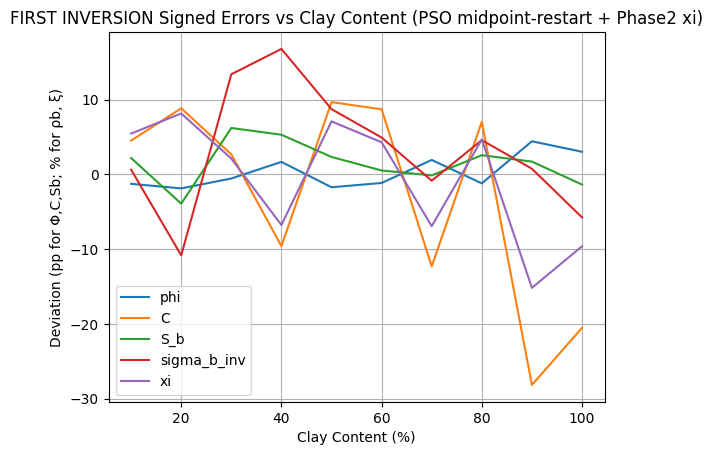

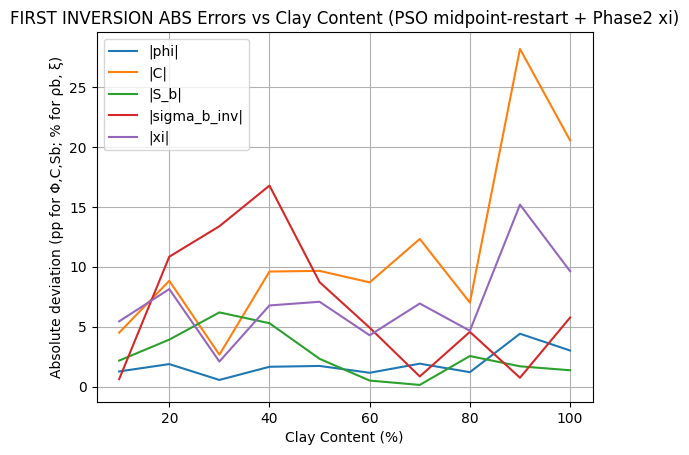

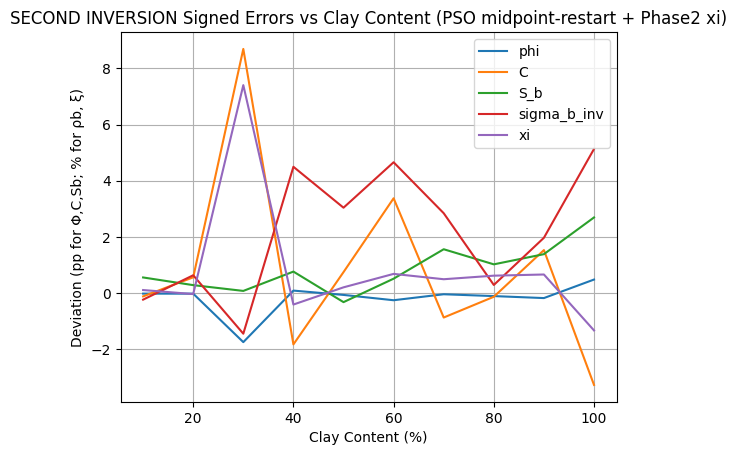

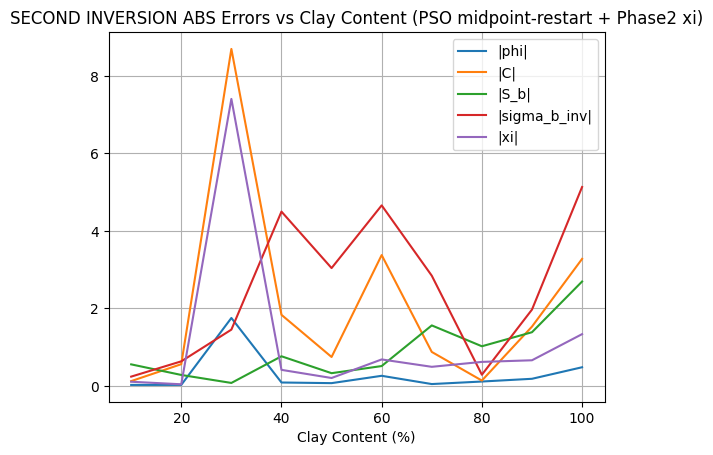


ABS averages:
 |devPHI| pp = 0.3025129303988642
 |devC|   pp = 2.1137871249338005
 |devSb|  pp = 0.9159363422071423
 |devROb|  % = 2.473698398078543
 |devxi|   % = 1.1942943306559015


In [2]:
from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit
import os

save_dir = os.path.expanduser("~/Units/Global and Multiobjective Optimization")
os.makedirs(save_dir, exist_ok=True)

#############################################################
# 1) Fixed physical parameters
#############################################################

@dataclass
class RockFluidConstants:
    # Quartz phase
    K_q: float = 37.3e9
    mu_q: float = 44.3e9
    rho_q: float = 2600.0
    sigma_q: float = 1e-6

    # Clay phase (second solid phase)
    K_c: float = 20.9e9
    mu_c: float = 6.9e9
    rho_c: float = 2650.0
    sigma_c: float = 0.1

    # Brine phase
    K_b: float = 2.25e9
    rho_b: float = 1030.0

    # Air phase
    K_a: float = 76e3
    rho_a: float = 1.2
    sigma_a: float = 1e-4


def const_to_array(c: RockFluidConstants) -> np.ndarray:
    return np.array(
        [
            c.K_q, c.mu_q, c.rho_q, c.sigma_q,
            c.K_c, c.mu_c, c.rho_c, c.sigma_c,
            c.K_b, c.rho_b,
            c.K_a, c.rho_a, c.sigma_a
        ],
        dtype=np.float64
    )


# constants array indices
K_q, mu_q, rho_q, sigma_q = 0, 1, 2, 3
K_c, mu_c, rho_c, sigma_c = 4, 5, 6, 7
K_b, rho_b = 8, 9
K_a, rho_a, sigma_a = 10, 11, 12


#############################################################
# 2) True model
#############################################################

@dataclass
class TrueModel:
    phi_percent: float
    C_percent: float
    S_b_percent: float
    sigma_b_inv: float
    xi: float


#############################################################
# 3) Forward Modelling
#############################################################

@njit(cache=True)
def compute_AK_Amu(C_percent: float):
    A_K = 0.025 * C_percent + 2.37
    A_mu = -0.003 * C_percent + 3.14
    return A_K, A_mu


@njit(cache=True)
def forward_model(phi_percent, C_percent, S_b_percent, sigma_b_inv, xi, const):
    eps = 1e-18

    phi = phi_percent / 100.0
    C = C_percent / 100.0
    S_b = S_b_percent / 100.0

    if abs(sigma_b_inv) < eps:
        return np.nan, np.nan, np.nan
    sigma_b = 1.0 / sigma_b_inv

    rho_s = (1.0 - C) * const[rho_q] + C * const[rho_c]
    rho_f = (1.0 - S_b) * const[rho_a] + S_b * const[rho_b]
    rho_bulk = (1.0 - phi) * rho_s + phi * rho_f
    if rho_bulk <= 0.0 or (not np.isfinite(rho_bulk)):
        return np.nan, np.nan, np.nan

    beta_q = 1.0 - C
    beta_c = C

    K_V = beta_q * const[K_q] + beta_c * const[K_c]
    mu_V = beta_q * const[mu_q] + beta_c * const[mu_c]
    if abs(K_V) < eps or abs(mu_V) < eps:
        return np.nan, np.nan, np.nan

    if const[K_q] >= const[K_c]:
        K_max = const[K_q]; K_min = const[K_c]
    else:
        K_max = const[K_c]; K_min = const[K_q]

    if const[mu_q] >= const[mu_c]:
        mu_max = const[mu_q]; mu_min = const[mu_c]
    else:
        mu_max = const[mu_c]; mu_min = const[mu_q]

    dK = const[K_c] - const[K_q]
    dmu = const[mu_c] - const[mu_q]
    if abs(dK) < eps or abs(dmu) < eps:
        return np.nan, np.nan, np.nan

    denom_plus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_max)
    denom_minus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_min)
    if abs(denom_plus) < eps or abs(denom_minus) < eps:
        return np.nan, np.nan, np.nan

    K_HS_plus = const[K_q] + (1.0 - beta_q) / denom_plus
    K_HS_minus = const[K_q] + (1.0 - beta_q) / denom_minus
    K_HS = 0.5 * (K_HS_plus + K_HS_minus)

    denom_hq = (K_max + 2.0 * mu_max)
    denom_hc = (K_min + 2.0 * mu_min)
    if abs(denom_hq) < eps or abs(denom_hc) < eps:
        return np.nan, np.nan, np.nan

    hs_shear_q = const[mu_q] + (mu_max / 6.0) * ((9.0 * K_max + 8.0 * mu_max) / denom_hq)
    hs_shear_c = const[mu_q] + (mu_min / 6.0) * ((9.0 * K_min + 8.0 * mu_min) / denom_hc)

    denom_mu_plus = (1.0 / dmu) + beta_q / hs_shear_q
    denom_mu_minus = (1.0 / dmu) + beta_q / hs_shear_c
    if abs(denom_mu_plus) < eps or abs(denom_mu_minus) < eps:
        return np.nan, np.nan, np.nan

    mu_HS_plus = const[mu_q] + (1.0 - beta_q) / denom_mu_plus
    mu_HS_minus = const[mu_q] + (1.0 - beta_q) / denom_mu_minus
    mu_HS = 0.5 * (mu_HS_plus + mu_HS_minus)

    A_K, A_mu = compute_AK_Amu(C_percent)

    denom = 1.0 - phi
    if denom <= 1e-15:
        return np.nan, np.nan, np.nan

    exponent_bulk = A_K / denom
    exponent_shear = xi * A_mu / denom

    one_minus_phi = 1.0 - phi
    bulk_factor = one_minus_phi ** exponent_bulk
    shear_factor = one_minus_phi ** exponent_shear

    K_m_q = (K_HS / K_V) * beta_q * const[K_q] * bulk_factor
    K_m_c = (K_HS / K_V) * beta_c * const[K_c] * bulk_factor
    K_m = K_m_q + K_m_c

    mu_m_q = (mu_HS / mu_V) * beta_q * const[mu_q] * shear_factor
    mu_m_c = (mu_HS / mu_V) * beta_c * const[mu_c] * shear_factor
    mu_m = mu_m_q + mu_m_c

    denom_Kf = (1.0 - S_b) / const[K_a] + S_b / const[K_b]
    if abs(denom_Kf) < eps:
        return np.nan, np.nan, np.nan
    K_f = 1.0 / denom_Kf

    alpha_q = beta_q - K_m_q / const[K_q]
    alpha_c = beta_c - K_m_c / const[K_c]

    phi_q_prime = alpha_q - beta_q * phi
    phi_c_prime = alpha_c - beta_c * phi

    M_inv = (phi_q_prime / const[K_q]) + (phi_c_prime / const[K_c]) + (phi / K_f)
    if (not np.isfinite(M_inv)) or abs(M_inv) < 1e-18:
        return np.nan, np.nan, np.nan

    M = 1.0 / M_inv
    K_G = K_m + (alpha_q + alpha_c) ** 2 * M
    mu_G = mu_m

    Vp = math.sqrt((K_G + (4.0 / 3.0) * mu_G) / rho_bulk)
    Vs = math.sqrt(mu_G / rho_bulk)

    gamma = 0.5
    term_sigma = (
        (1.0 - phi) * (1.0 - C) * (const[sigma_q] ** gamma) +
        (1.0 - phi) * C * (const[sigma_c] ** gamma) +
        phi * S_b * (sigma_b ** gamma) +
        phi * (1.0 - S_b) * (const[sigma_a] ** gamma)
    )

    if (not np.isfinite(term_sigma)) or term_sigma <= 0.0:
        return np.nan, np.nan, np.nan

    sigma_bulk = term_sigma ** (1.0 / gamma)
    return Vp, Vs, sigma_bulk



#############################################################
# MISFIT
#############################################################

@njit(cache=True)
def objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2):
    if (not np.isfinite(Vp_T)) or (not np.isfinite(Vs_T)) or (not np.isfinite(sigma_T)) or sigma_T <= 0.0:
        return 1e300

    Vp, Vs, sigma = forward_model(x[0], x[1], x[2], x[3], x[4], const)

    if (not np.isfinite(Vp)) or (not np.isfinite(Vs)) or (not np.isfinite(sigma)) or sigma <= 0.0:
        return 1e300

    return (
        abs(Vp - Vp_T)
        + W1 * abs(Vs - Vs_T)
        + W2 * abs((1.0 / sigma) - (1.0 / sigma_T))
    )


#############################################################
# 4) PSO in normalized space y ∈ [0,1]^5
#############################################################

@njit(cache=True)
def randn_box_muller():
    u1 = np.random.random()
    u2 = np.random.random()
    if u1 < 1e-16:
        u1 = 1e-16
    return math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)

# To mantain velocities inside some bounds
@njit(cache=True)
def clamp_velocity_component(v, vmax, vmin):
    av = abs(v)
    if av > vmax:
        return math.copysign(vmax, v)
    if vmin > 0.0 and av < vmin and av > 0.0:
        return math.copysign(vmin, v)
    return v

# Boundary Reflection Conditions
@njit(cache=True)
def reflect_01(y, v):
    while y < 0.0 or y > 1.0:
        if y < 0.0:
            y = -y
            v = -v
        elif y > 1.0:
            y = 2.0 - y
            v = -v
    if y < 0.0:
        y = 0.0
    elif y > 1.0:
        y = 1.0
    return y, v

# Mapping from the normalized space in real space
@njit(cache=True)
def map_y_to_x(y, lo, hi, x_out):
    for j in range(5):
        x_out[j] = lo[j] + y[j] * (hi[j] - lo[j])

#Check on the validity
@njit(cache=True)
def outside_01(y_row):
    for j in range(5):
        if y_row[j] < 0.0 or y_row[j] > 1.0:
            return True
    return False


# =============================================================================================
# PSO:
# init_mode:
#   - if init_mode is 0 the cloud is generated with uniform distribution ont the search space
#   - if init_mode is 1 the cloud is generated with gaussian distribution around the midpoit
# =============================================================================================

@njit(cache=True)
def pso_single_norm(
    Vp_T, Vs_T, sigma_T,
    const,
    lo, hi,
    n_particles,
    n_iters,
    W1, W2,
    tol,
    w_start, w_end,
    c_soc, c_cog,
    vmax_abs, vmin_abs,
    seed,
    init_mode,      
    init_sigma_y,   # std dev in normalized space around center (only if init_mode=1)
    zero_vel,
    eps_improve,
    patience
):
    np.random.seed(seed)

    dim = 5
    Xtmp = np.empty(dim, dtype=np.float64)

    Y = np.empty((n_particles, dim), dtype=np.float64)
    V = np.empty((n_particles, dim), dtype=np.float64)

    PbestY = np.empty((n_particles, dim), dtype=np.float64)
    Fpbest = np.empty(n_particles, dtype=np.float64)

    # -----------------------------
    # Initialization (similar to paper: midpoint of bounds)
    # -----------------------------
    center = 0.5


    for i in range(n_particles):
        for j in range(dim):
            if init_mode == 1:
                # one particle exactly at the center, others around the center
                if i == 0:
                    y = center
                else:
                    y = center + init_sigma_y * randn_box_muller()
                    # keep y inside [0,1] using reflection 
                    y, _ = reflect_01(y, 0.0)
            else:
                # uniform in [0,1]
                y = np.random.random()

            Y[i, j] = y

            if zero_vel == 1:
                V[i, j] = 0.0
            else:
                V[i, j] = (2.0 * np.random.random() - 1.0) * vmax_abs

        Fpbest[i] = 1e300

    # -----------------------------
    # Initial evaluation
    # -----------------------------
    gbestY = np.empty(dim, dtype=np.float64)
    f_gbest = 1e300

    for i in range(n_particles):
        if outside_01(Y[i]):
            f = 1e300
        else:
            map_y_to_x(Y[i], lo, hi, Xtmp)
            f = objective(Xtmp, Vp_T, Vs_T, sigma_T, const, W1, W2)

        Fpbest[i] = f
        for j in range(dim):
            PbestY[i, j] = Y[i, j]

        if f < f_gbest:
            f_gbest = f
            for j in range(dim):
                gbestY[j] = Y[i, j]

    stop_reason = 0  # 0=none, 1=tol, 2=patience, 3=max_iters
    stop_iter = 0

    if f_gbest <= tol:
        stop_reason = 1
        stop_iter = 0
        map_y_to_x(gbestY, lo, hi, Xtmp)
        return Xtmp.copy(), f_gbest, stop_iter, stop_reason

    best_seen = f_gbest
    no_improve = 0

    # -----------------------------
    # Main PSO loop
    # -----------------------------
    for it in range(1, n_iters + 1):
        t = (it - 1) / max(1, (n_iters - 1))
        w = w_start + (w_end - w_start) * t

        for i in range(n_particles):
            for j in range(dim):
                r1 = np.random.random()
                r2 = np.random.random()

                v_new = (
                    w * V[i, j]
                    + c_soc * r1 * (gbestY[j] - Y[i, j])
                    + c_cog * r2 * (PbestY[i, j] - Y[i, j])
                )
                v_new = clamp_velocity_component(v_new, vmax_abs, vmin_abs)

                y_new = Y[i, j] + v_new
                y_new, v_new = reflect_01(y_new, v_new)

                Y[i, j] = y_new
                V[i, j] = v_new

            if outside_01(Y[i]):
                f = 1e300
            else:
                map_y_to_x(Y[i], lo, hi, Xtmp)
                f = objective(Xtmp, Vp_T, Vs_T, sigma_T, const, W1, W2)

            if f < Fpbest[i]:
                Fpbest[i] = f
                for j in range(dim):
                    PbestY[i, j] = Y[i, j]

                if f < f_gbest:
                    f_gbest = f
                    for j in range(dim):
                        gbestY[j] = Y[i, j]

        if f_gbest <= tol:
            stop_reason = 1
            stop_iter = it
            break

        thr = eps_improve * max(1.0, best_seen)
        if best_seen - f_gbest > thr:
            best_seen = f_gbest
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                stop_reason = 2
                stop_iter = it
                break

    if stop_reason == 0:
        stop_reason = 3
        stop_iter = n_iters

    map_y_to_x(gbestY, lo, hi, Xtmp)
    return Xtmp.copy(), f_gbest, stop_iter, stop_reason


#############################################################
# Utilities
#############################################################

def add_relative_noise(rng: np.random.Generator, x: float, rel_std: float = 0.01) -> float:
    return x * (1.0 + rng.normal(0.0, rel_std))

def dev_points(out_percent: float, inp_percent: float) -> float:
    return out_percent - inp_percent

def dev_rel_percent(out: float, inp: float) -> float:
    eps = 1e-18
    denom = inp if abs(inp) > eps else eps
    return 100.0 * (out - inp) / denom


#############################################################
# MAIN
#############################################################

if __name__ == "__main__":
    W1 = 1.0
    W2 = 100.0
    tol1 = 1e-9
    tol2 = 1e-9

    reason_map = {0: "none", 1: "tol", 2: "patience", 3: "max_iters"}

    lo = np.array([0.0,   0.0,  80.0,  0.2, 1.0], dtype=np.float64)
    hi = np.array([70.0, 100.0, 100.0, 25.0, 3.0], dtype=np.float64)

    lo2 = lo.copy()
    hi2 = hi.copy()
    lo2[4] = 2.5
    hi2[4] = 2.9

    const = const_to_array(RockFluidConstants())

    c_soc1 = 1.49445
    c_cog1 = 1.49445
    c_soc2 = 1.49445
    c_cog2 = 1.49445
    w_start1 = 0.9
    w_end1   = 0.4
    w_start2 = 0.2
    w_end2   = 0.02

    vmax_abs_phase1 = 0.20
    vmax_abs_phase2 = 0.02
    vmin_abs = 0.0

    N_PART_PHASE1 = 499 
    N_PART_PHASE2 = 1996 
    N_ITERS_PHASE1 = 2000 
    N_ITERS_PHASE2 = 500 

    
    INIT_MODE_PHASE1 = 1
    INIT_MODE_PHASE2 = 1
    INIT_SIGMA_Y_PHASE1 = 0.10   # spread around midpoint in phase 1
    INIT_SIGMA_Y_PHASE2 = 0.02  # tighter spread around midpoint in phase 2

    ZERO_VEL_PHASE1 = 0
    ZERO_VEL_PHASE2 = 0

    EPS_IMPROVE = 1e-6
    PATIENCE1 = 4000
    PATIENCE2 = 1000

    err_phi1, err_C1, err_Sb1, err_rhob1, err_xi1 = [], [], [], [], []
    aerr_phi1, aerr_C1, aerr_Sb1, aerr_rhob1, aerr_xi1 = [], [], [], [], []
    C_content1 = []

    err_phi2, err_C2, err_Sb2, err_rhob2, err_xi2 = [], [], [], [], []
    aerr_phi2, aerr_C2, aerr_Sb2, aerr_rhob2, aerr_xi2 = [], [], [], [], []
    C_content2 = []

    seed_noise = 369
    seed_run_phase1 = 123
    seed_run_phase2 = 246
    rng = np.random.default_rng(seed=seed_noise)

    # warm-up compilation
    safe_x = np.array([41.0, 20.0, 90.0, 0.5, 2.7], dtype=np.float64)
    Vp_s, Vs_s, sig_s = forward_model(safe_x[0], safe_x[1], safe_x[2], safe_x[3], safe_x[4], const)
    _ = objective(safe_x, float(Vp_s), float(Vs_s), float(sig_s), const, W1, W2)

    _ = pso_single_norm(
        float(Vp_s), float(Vs_s), float(sig_s),
        const, lo, hi,
        8, 5, W1, W2, tol1,
        w_start1, w_end1, c_soc1, c_cog1,
        0.2, 0.0,
        492,
        1, 0.10, 0,
        1e-12, 5
    )
    _ = pso_single_norm(
        float(Vp_s), float(Vs_s), float(sig_s),
        const, lo2, hi2,
        8, 5, W1, W2, tol2,
        w_start2, w_end2, c_soc2, c_cog2,
        0.02, 0.0,
        493,
        1, 0.02, 1,
        1e-12, 5
    )

    for k in range(0, 100, 10):
        print("\n" + "=" * 70)
        print(f"RUN k = {k}")
        print("=" * 70)

        true_model = TrueModel(
            phi_percent=41.0,
            C_percent=10.0 + k,
            S_b_percent=90.0,
            sigma_b_inv=0.5,
            xi=2.7
        )

        

        Vp_true, Vs_true, sigma_true = forward_model(
            true_model.phi_percent, true_model.C_percent, true_model.S_b_percent,
            true_model.sigma_b_inv, true_model.xi, const
        )

        Vp_obs = add_relative_noise(rng, float(Vp_true), 0.01)
        Vs_obs = add_relative_noise(rng, float(Vs_true), 0.01)
        sigma_obs = add_relative_noise(rng, float(sigma_true), 0.01)

        # Phase 1
        best1, f1, it1, reason1 = pso_single_norm(
            Vp_obs, Vs_obs, sigma_obs,
            const, lo, hi,
            N_PART_PHASE1, N_ITERS_PHASE1,
            W1, W2, tol1,
            w_start1, w_end1, c_soc1, c_cog1,
            vmax_abs_phase1, vmin_abs,
            seed_run_phase1 + k,
            INIT_MODE_PHASE1, INIT_SIGMA_Y_PHASE1, ZERO_VEL_PHASE1,
            EPS_IMPROVE, PATIENCE1
        )

        print("\n=== Phase 1 PSO (normalized, midpoint init) ===")
        print(f"Best objective f = {f1:.6e}")
        print(f"Stopped at iter = {it1} (reason={reason_map.get(reason1,'?')})")
        print(f"  phi_percent   = {best1[0]:.6f}")
        print(f"  C_percent     = {best1[1]:.6f}")
        print(f"  S_b_percent   = {best1[2]:.6f}")
        print(f"  sigma_b_inv   = {best1[3]:.6f}")
        print(f"  xi            = {best1[4]:.6f}")



         # deviations
        e_phi = dev_points(best1[0], true_model.phi_percent)
        e_C   = dev_points(best1[1], true_model.C_percent)
        e_Sb  = dev_points(best1[2], true_model.S_b_percent)
        e_rb  = dev_rel_percent(best1[3], true_model.sigma_b_inv)
        e_xi  = dev_rel_percent(best1[4], true_model.xi)



        err_phi1.append(e_phi); err_C1.append(e_C); err_Sb1.append(e_Sb); err_rhob1.append(e_rb); err_xi1.append(e_xi)
        aerr_phi1.append(abs(e_phi)); aerr_C1.append(abs(e_C)); aerr_Sb1.append(abs(e_Sb)); aerr_rhob1.append(abs(e_rb)); aerr_xi1.append(abs(e_xi))
        C_content1.append(true_model.C_percent)
        

        # Phase 2
        best2, f2, it2, reason2 = pso_single_norm(
            Vp_obs, Vs_obs, sigma_obs,
            const, lo2, hi2,
            N_PART_PHASE2, N_ITERS_PHASE2,
            W1, W2, tol2,
            w_start2, w_end2, c_soc2, c_cog2,
            vmax_abs_phase2, vmin_abs,
            seed_run_phase2 + k,
            INIT_MODE_PHASE2, INIT_SIGMA_Y_PHASE2, ZERO_VEL_PHASE2,
            EPS_IMPROVE, PATIENCE2
        )

        print("\n=== Phase 2 PSO (xi in [2.5, 2.9], midpoint restart) ===")
        print(f"Best objective f = {f2:.6e}")
        print(f"Stopped at iter = {it2} (reason={reason_map.get(reason2,'?')})")
        print(f"  phi_percent   = {best2[0]:.6f}")
        print(f"  C_percent     = {best2[1]:.6f}")
        print(f"  S_b_percent   = {best2[2]:.6f}")
        print(f"  sigma_b_inv   = {best2[3]:.6f}")
        print(f"  xi            = {best2[4]:.6f}")

        # deviations
        e_phi = dev_points(best2[0], true_model.phi_percent)
        e_C   = dev_points(best2[1], true_model.C_percent)
        e_Sb  = dev_points(best2[2], true_model.S_b_percent)
        e_rb  = dev_rel_percent(best2[3], true_model.sigma_b_inv)
        e_xi  = dev_rel_percent(best2[4], true_model.xi)

        err_phi2.append(e_phi); err_C2.append(e_C); err_Sb2.append(e_Sb); err_rhob2.append(e_rb); err_xi2.append(e_xi)
        aerr_phi2.append(abs(e_phi)); aerr_C2.append(abs(e_C)); aerr_Sb2.append(abs(e_Sb)); aerr_rhob2.append(abs(e_rb)); aerr_xi2.append(abs(e_xi))
        C_content2.append(true_model.C_percent)


    # plots
    plt.figure()
    plt.plot(C_content1, err_phi1, label="phi")
    plt.plot(C_content1, err_C1, label="C")
    plt.plot(C_content1, err_Sb1, label="S_b")
    plt.plot(C_content1, err_rhob1, label="sigma_b_inv")
    plt.plot(C_content1, err_xi1, label="xi")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("FIRST INVERSION Signed Errors vs Clay Content (PSO midpoint-restart + Phase2 xi)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "PSO_signed_errors_vs_clay.png"), dpi=300)
    plt.show()

    plt.figure()
    plt.plot(C_content1, aerr_phi1, label="|phi|")
    plt.plot(C_content1, aerr_C1, label="|C|")
    plt.plot(C_content1, aerr_Sb1, label="|S_b|")
    plt.plot(C_content1, aerr_rhob1, label="|sigma_b_inv|")
    plt.plot(C_content1, aerr_xi1, label="|xi|")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Absolute deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("FIRST INVERSION ABS Errors vs Clay Content (PSO midpoint-restart + Phase2 xi)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "PSO_abs_errors_vs_clay.png"), dpi=300)
    plt.show()



    
    # plots
    plt.figure()
    plt.plot(C_content2, err_phi2, label="phi")
    plt.plot(C_content2, err_C2, label="C")
    plt.plot(C_content2, err_Sb2, label="S_b")
    plt.plot(C_content2, err_rhob2, label="sigma_b_inv")
    plt.plot(C_content2, err_xi2, label="xi")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("SECOND INVERSION Signed Errors vs Clay Content (PSO midpoint-restart + Phase2 xi)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "PSO_signed_errors_vs_clay.png"), dpi=300)
    plt.show()

    plt.figure()
    plt.plot(C_content2, aerr_phi2, label="|phi|")
    plt.plot(C_content2, aerr_C2, label="|C|")
    plt.plot(C_content2, aerr_Sb2, label="|S_b|")
    plt.plot(C_content2, aerr_rhob2, label="|sigma_b_inv|")
    plt.plot(C_content2, aerr_xi2, label="|xi|")
    plt.xlabel("Clay Content (%)")
    #plt.ylabel("Absolute deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("SECOND INVERSION ABS Errors vs Clay Content (PSO midpoint-restart + Phase2 xi)")
    plt.legend()
    plt.grid(True)
    #plt.savefig(os.path.join(save_dir, "PSO_abs_errors_vs_clay.png"), dpi=300)
    plt.show()

    print("\nABS averages:")
    print(" |devPHI| pp =", np.mean(aerr_phi2))
    print(" |devC|   pp =", np.mean(aerr_C2))
    print(" |devSb|  pp =", np.mean(aerr_Sb2))
    print(" |devROb|  % =", np.mean(aerr_rhob2))
    print(" |devxi|   % =", np.mean(aerr_xi2))

# CMA-ES


RUN k = 0

=== Phase 1 CMA-ES (normalized, midpoint init) ===
Best objective f = 2.494183e-11
Evaluations = 30000
  phi_percent   = 40.061924
  C_percent     = 14.022241
  S_b_percent   = 90.805692
  sigma_b_inv   = 0.500710
  xi            = 2.815294

=== Phase 2 CMA-ES (xi in [2.5, 2.9], midpoint restart) ===
Best objective f = 1.698197e-12
Evaluations = 60000
  phi_percent   = 40.156538
  C_percent     = 14.450440
  S_b_percent   = 80.574079
  sigma_b_inv   = 0.397915
  xi            = 2.808910

RUN k = 10

=== Phase 1 CMA-ES (normalized, midpoint init) ===
Best objective f = 1.878853e-11
Evaluations = 30000
  phi_percent   = 40.099171
  C_percent     = 23.348593
  S_b_percent   = 92.057075
  sigma_b_inv   = 0.515726
  xi            = 2.789923

=== Phase 2 CMA-ES (xi in [2.5, 2.9], midpoint restart) ===
Best objective f = 3.854694e-13
Evaluations = 60000
  phi_percent   = 39.371618
  C_percent     = 27.203755
  S_b_percent   = 82.439242
  sigma_b_inv   = 0.411889
  xi            = 

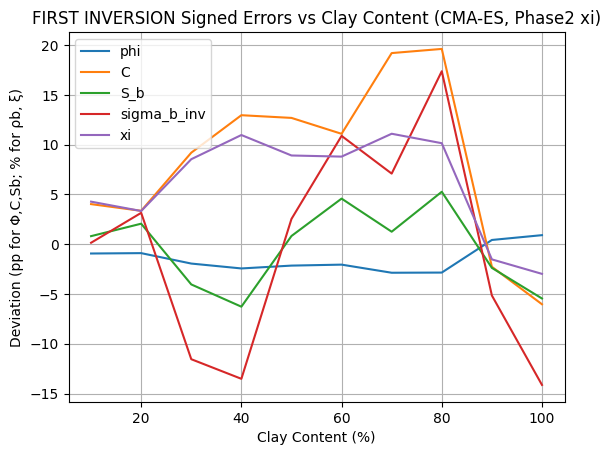

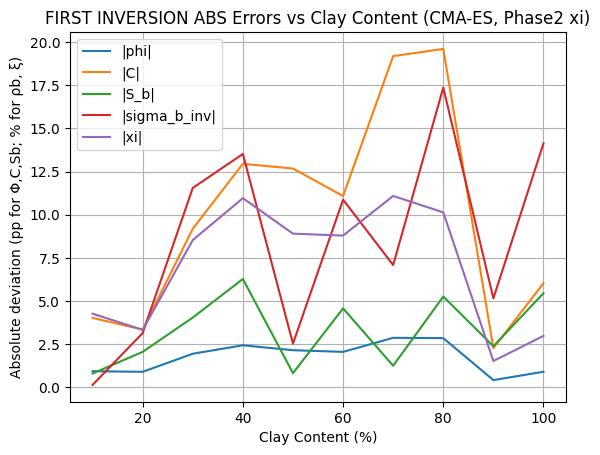

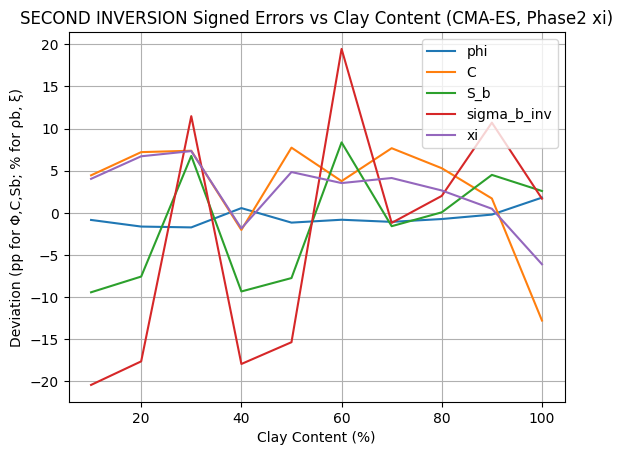

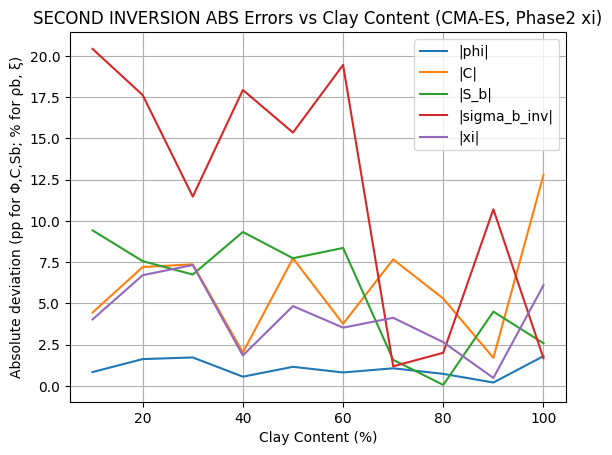


ABS averages:
 |devPHI| pp = 1.0561604139823928
 |devC|   pp = 5.99921078497959
 |devSb|  pp = 5.790379968099896
 |devROb|  % = 11.7830213710501
 |devxi|   % = 4.166365188928512


In [ ]:
from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit
import os
import cma


save_dir = os.path.expanduser("~/Units/Global and Multiobjective Optimization")
os.makedirs(save_dir, exist_ok=True)

#############################################################
# 1) Fixed physical parameters
#############################################################

@dataclass
class RockFluidConstants:
    # Quartz phase
    K_q: float = 37.3e9
    mu_q: float = 44.3e9
    rho_q: float = 2600.0
    sigma_q: float = 1e-6

    # Clay phase (second solid phase)
    K_c: float = 20.9e9
    mu_c: float = 6.9e9
    rho_c: float = 2650.0
    sigma_c: float = 0.1

    # Brine phase
    K_b: float = 2.25e9
    rho_b: float = 1030.0

    # Air phase
    K_a: float = 76e3
    rho_a: float = 1.2
    sigma_a: float = 1e-4


def const_to_array(c: RockFluidConstants) -> np.ndarray:
    return np.array(
        [
            c.K_q, c.mu_q, c.rho_q, c.sigma_q,
            c.K_c, c.mu_c, c.rho_c, c.sigma_c,
            c.K_b, c.rho_b,
            c.K_a, c.rho_a, c.sigma_a
        ],
        dtype=np.float64
    )


# constants array indices
K_q, mu_q, rho_q, sigma_q = 0, 1, 2, 3
K_c, mu_c, rho_c, sigma_c = 4, 5, 6, 7
K_b, rho_b = 8, 9
K_a, rho_a, sigma_a = 10, 11, 12


#############################################################
# 2) True model
#############################################################

@dataclass
class TrueModel:
    phi_percent: float
    C_percent: float
    S_b_percent: float
    sigma_b_inv: float
    xi: float


#############################################################
# 3) Forward modelling
#############################################################

@njit(cache=True)
def compute_AK_Amu(C_percent: float):
    A_K = 0.025 * C_percent + 2.37
    A_mu = -0.003 * C_percent + 3.14
    return A_K, A_mu


@njit(cache=True)
def forward_model(phi_percent, C_percent, S_b_percent, sigma_b_inv, xi, const):
    eps = 1e-18

    phi = phi_percent / 100.0
    C = C_percent / 100.0
    S_b = S_b_percent / 100.0

    if abs(sigma_b_inv) < eps:
        return np.nan, np.nan, np.nan
    sigma_b = 1.0 / sigma_b_inv

    rho_s = (1.0 - C) * const[rho_q] + C * const[rho_c]
    rho_f = (1.0 - S_b) * const[rho_a] + S_b * const[rho_b]
    rho_bulk = (1.0 - phi) * rho_s + phi * rho_f
    if rho_bulk <= 0.0 or (not np.isfinite(rho_bulk)):
        return np.nan, np.nan, np.nan

    beta_q = 1.0 - C
    beta_c = C

    K_V = beta_q * const[K_q] + beta_c * const[K_c]
    mu_V = beta_q * const[mu_q] + beta_c * const[mu_c]
    if abs(K_V) < eps or abs(mu_V) < eps:
        return np.nan, np.nan, np.nan

    if const[K_q] >= const[K_c]:
        K_max = const[K_q]; K_min = const[K_c]
    else:
        K_max = const[K_c]; K_min = const[K_q]

    if const[mu_q] >= const[mu_c]:
        mu_max = const[mu_q]; mu_min = const[mu_c]
    else:
        mu_max = const[mu_c]; mu_min = const[mu_q]

    dK = const[K_c] - const[K_q]
    dmu = const[mu_c] - const[mu_q]
    if abs(dK) < eps or abs(dmu) < eps:
        return np.nan, np.nan, np.nan

    denom_plus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_max)
    denom_minus = (1.0 / dK) + beta_q / (const[K_q] + (4.0 / 3.0) * mu_min)
    if abs(denom_plus) < eps or abs(denom_minus) < eps:
        return np.nan, np.nan, np.nan

    K_HS_plus = const[K_q] + (1.0 - beta_q) / denom_plus
    K_HS_minus = const[K_q] + (1.0 - beta_q) / denom_minus
    K_HS = 0.5 * (K_HS_plus + K_HS_minus)

    denom_hq = (K_max + 2.0 * mu_max)
    denom_hc = (K_min + 2.0 * mu_min)
    if abs(denom_hq) < eps or abs(denom_hc) < eps:
        return np.nan, np.nan, np.nan

    hs_shear_q = const[mu_q] + (mu_max / 6.0) * ((9.0 * K_max + 8.0 * mu_max) / denom_hq)
    hs_shear_c = const[mu_q] + (mu_min / 6.0) * ((9.0 * K_min + 8.0 * mu_min) / denom_hc)

    denom_mu_plus = (1.0 / dmu) + beta_q / hs_shear_q
    denom_mu_minus = (1.0 / dmu) + beta_q / hs_shear_c
    if abs(denom_mu_plus) < eps or abs(denom_mu_minus) < eps:
        return np.nan, np.nan, np.nan

    mu_HS_plus = const[mu_q] + (1.0 - beta_q) / denom_mu_plus
    mu_HS_minus = const[mu_q] + (1.0 - beta_q) / denom_mu_minus
    mu_HS = 0.5 * (mu_HS_plus + mu_HS_minus)

    A_K, A_mu = compute_AK_Amu(C_percent)

    denom = 1.0 - phi
    if denom <= 1e-15:
        return np.nan, np.nan, np.nan

    exponent_bulk = A_K / denom
    exponent_shear = xi * A_mu / denom

    one_minus_phi = 1.0 - phi
    bulk_factor = one_minus_phi ** exponent_bulk
    shear_factor = one_minus_phi ** exponent_shear

    K_m_q = (K_HS / K_V) * beta_q * const[K_q] * bulk_factor
    K_m_c = (K_HS / K_V) * beta_c * const[K_c] * bulk_factor
    K_m = K_m_q + K_m_c

    mu_m_q = (mu_HS / mu_V) * beta_q * const[mu_q] * shear_factor
    mu_m_c = (mu_HS / mu_V) * beta_c * const[mu_c] * shear_factor
    mu_m = mu_m_q + mu_m_c

    denom_Kf = (1.0 - S_b) / const[K_a] + S_b / const[K_b]
    if abs(denom_Kf) < eps:
        return np.nan, np.nan, np.nan
    K_f = 1.0 / denom_Kf

    alpha_q = beta_q - K_m_q / const[K_q]
    alpha_c = beta_c - K_m_c / const[K_c]

    phi_q_prime = alpha_q - beta_q * phi
    phi_c_prime = alpha_c - beta_c * phi

    M_inv = (phi_q_prime / const[K_q]) + (phi_c_prime / const[K_c]) + (phi / K_f)
    if (not np.isfinite(M_inv)) or abs(M_inv) < 1e-18:
        return np.nan, np.nan, np.nan

    M = 1.0 / M_inv
    K_G = K_m + (alpha_q + alpha_c) ** 2 * M
    mu_G = mu_m

    Vp = math.sqrt((K_G + (4.0 / 3.0) * mu_G) / rho_bulk)
    Vs = math.sqrt(mu_G / rho_bulk)

    gamma = 0.5
    term_sigma = (
        (1.0 - phi) * (1.0 - C) * (const[sigma_q] ** gamma) +
        (1.0 - phi) * C * (const[sigma_c] ** gamma) +
        phi * S_b * (sigma_b ** gamma) +
        phi * (1.0 - S_b) * (const[sigma_a] ** gamma)
    )

    if (not np.isfinite(term_sigma)) or term_sigma <= 0.0:
        return np.nan, np.nan, np.nan

    sigma_bulk = term_sigma ** (1.0 / gamma)
    return Vp, Vs, sigma_bulk


#############################################################
# MISFIT
#############################################################

@njit(cache=True)
def objective(x, Vp_T, Vs_T, sigma_T, const, W1, W2):
    if (not np.isfinite(Vp_T)) or (not np.isfinite(Vs_T)) or (not np.isfinite(sigma_T)) or sigma_T <= 0.0:
        return 1e300

    Vp, Vs, sigma = forward_model(x[0], x[1], x[2], x[3], x[4], const)

    if (not np.isfinite(Vp)) or (not np.isfinite(Vs)) or (not np.isfinite(sigma)) or sigma <= 0.0:
        return 1e300

    return (
        abs(Vp - Vp_T)
        + W1 * abs(Vs - Vs_T)
        + W2 * abs((1.0 / sigma) - (1.0 / sigma_T))
    )


#############################################################
# 4) CMA-ES in normalized space y ∈ [0,1]^5
#############################################################

def cma_single_norm(
    Vp_T, Vs_T, sigma_T,
    const,
    lo, hi,
    W1, W2,
    tol,
    seed,
    max_evals=30000,
    popsize=32,
    init_sigma_y=0.15,
    init_mode=1
):
    dim = 5
    lo = np.asarray(lo, dtype=np.float64)
    hi = np.asarray(hi, dtype=np.float64)
    span = hi - lo

    def y_to_x(y):
        y = np.asarray(y, dtype=np.float64)
        return lo + y * span

    def f_y(y):
        y = np.asarray(y, dtype=np.float64)
        if np.any(y < 0.0) or np.any(y > 1.0) or (not np.all(np.isfinite(y))):
            return 1e300
        x = y_to_x(y)
        return float(objective(
            x, float(Vp_T), float(Vs_T), float(sigma_T),
            const, float(W1), float(W2)
        ))

    rng = np.random.default_rng(int(seed))
    if init_mode == 1:
        y0 = np.full(dim, 0.5, dtype=np.float64)
    else:
        y0 = rng.random(dim)

    opts = {
        "bounds": [0.0, 1.0],
        "seed": int(seed),
        "verb_disp": 0,
        "verbose": -9,
        "maxfevals": int(max_evals),
        "popsize": int(popsize),

        # Avoid other stopping criteria to force the use of the max number of evaluations
        "tolfun": 0.0,
        "tolx": 0.0,
        "tolfunhist": 0.0,
        "tolstagnation": int(10**9),
        "maxiter": int(10**9),
    }

    es = cma.CMAEvolutionStrategy(y0.tolist(), float(init_sigma_y), opts)

    # 1) Use only entire size populations popsize
    while es.countevals + es.sp.popsize <= max_evals:
        Y = es.ask()                 # len(Y) == popsize
        F = [f_y(y) for y in Y]
        es.tell(Y, F)

    # 2) Use the remaining population if it is less than popsize
    remaining = max_evals - es.countevals
    y_best_extra = None
    f_best_extra = 1e300

    if remaining > 0:
        Y_extra = es.ask()[:remaining]
        F_extra = [f_y(y) for y in Y_extra]

        # track del best nelle extra-eval
        for y, f in zip(Y_extra, F_extra):
            if f < f_best_extra:
                f_best_extra = f
                y_best_extra = np.array(y, dtype=np.float64)

    y_best = np.clip(np.array(es.result.xbest, dtype=np.float64), 0.0, 1.0)
    f_best = float(es.result.fbest)

    # update best
    if y_best_extra is not None and f_best_extra < f_best:
        y_best = np.clip(y_best_extra, 0.0, 1.0)
        f_best = float(f_best_extra)

    x_best = y_to_x(y_best)

    # budget consumato esattamente
    evals = int(max_evals)
    return x_best, f_best, evals


#############################################################
# Utilities
#############################################################

def add_relative_noise(rng: np.random.Generator, x: float, rel_std: float = 0.01) -> float:
    return x * (1.0 + rng.normal(0.0, rel_std))

def dev_points(out_percent: float, inp_percent: float) -> float:
    return out_percent - inp_percent

def dev_rel_percent(out: float, inp: float) -> float:
    eps = 1e-18
    denom = inp if abs(inp) > eps else eps
    return 100.0 * (out - inp) / denom


#############################################################
# MAIN
#############################################################

if __name__ == "__main__":
    W1 = 1.0
    W2 = 100.0
    tol1 = 1e-12
    tol2 = 1e-12

    lo = np.array([0.0,   0.0,  80.0,  0.2, 1.0], dtype=np.float64)
    hi = np.array([70.0, 100.0, 100.0, 25.0, 3.0], dtype=np.float64)

    lo2 = lo.copy()
    hi2 = hi.copy()
    #lo2[3]=10
    #hi2[3]=20
    lo2[4] = 2.5
    hi2[4] = 2.9

    const = const_to_array(RockFluidConstants())

    # CMA-ES hyperparameters
    MAX_EVALS_PHASE1 = 30000 
    POPSIZE_PHASE1 = 96 
    INIT_SIGMA_Y_PHASE1 = 0.15 

    MAX_EVALS_PHASE2 = 60000 
    POPSIZE_PHASE2 = 64 
    INIT_SIGMA_Y_PHASE2 = 0.5 


    err_phi1, err_C1, err_Sb1, err_rhob1, err_xi1 = [], [], [], [], []
    aerr_phi1, aerr_C1, aerr_Sb1, aerr_rhob1, aerr_xi1 = [], [], [], [], []
    C_content1 = []

    err_phi2, err_C2, err_Sb2, err_rhob2, err_xi2 = [], [], [], [], []
    aerr_phi2, aerr_C2, aerr_Sb2, aerr_rhob2, aerr_xi2 = [], [], [], [], []
    C_content2 = []

    rng = np.random.default_rng(seed=369)

    # warm-up compilation 
    safe_x = np.array([41.0, 20.0, 90.0, 0.5, 2.7], dtype=np.float64)
    Vp_s, Vs_s, sig_s = forward_model(safe_x[0], safe_x[1], safe_x[2], safe_x[3], safe_x[4], const)
    _ = objective(safe_x, float(Vp_s), float(Vs_s), float(sig_s), const, W1, W2)

    for k in range(0, 100, 10):
        print("\n" + "=" * 70)
        print(f"RUN k = {k}")
        print("=" * 70)

        true_model = TrueModel(
            phi_percent=41.0,
            C_percent=10.0 + k,
            S_b_percent=90.0,
            sigma_b_inv=0.5,
            xi=2.7
        )
        

        Vp_true, Vs_true, sigma_true = forward_model(
            true_model.phi_percent, true_model.C_percent, true_model.S_b_percent,
            true_model.sigma_b_inv, true_model.xi, const
        )

        Vp_obs = add_relative_noise(rng, float(Vp_true), 0.01)
        Vs_obs = add_relative_noise(rng, float(Vs_true), 0.01)
        sigma_obs = add_relative_noise(rng, float(sigma_true), 0.01)

        # Phase 1 
        best1, f1, evals1 = cma_single_norm(
            Vp_obs, Vs_obs, sigma_obs,
            const, lo, hi,
            W1, W2,
            tol=tol1,
            seed=1233 + k,
            max_evals=MAX_EVALS_PHASE1,
            popsize=POPSIZE_PHASE1,
            init_sigma_y=INIT_SIGMA_Y_PHASE1,
            init_mode=1
        )

        assert evals1 == MAX_EVALS_PHASE1, (evals1, MAX_EVALS_PHASE1)

        print("\n=== Phase 1 CMA-ES (normalized, midpoint init) ===")
        print(f"Best objective f = {f1:.6e}")
        print(f"Evaluations = {evals1}")
        print(f"  phi_percent   = {best1[0]:.6f}")
        print(f"  C_percent     = {best1[1]:.6f}")
        print(f"  S_b_percent   = {best1[2]:.6f}")
        print(f"  sigma_b_inv   = {best1[3]:.6f}")
        print(f"  xi            = {best1[4]:.6f}")


        # deviations 
        e_phi = dev_points(best1[0], true_model.phi_percent)
        e_C   = dev_points(best1[1], true_model.C_percent)
        e_Sb  = dev_points(best1[2], true_model.S_b_percent)
        e_rb  = dev_rel_percent(best1[3], true_model.sigma_b_inv)
        e_xi  = dev_rel_percent(best1[4], true_model.xi)

        

        err_phi1.append(e_phi); err_C1.append(e_C); err_Sb1.append(e_Sb); err_rhob1.append(e_rb); err_xi1.append(e_xi)
        aerr_phi1.append(abs(e_phi)); aerr_C1.append(abs(e_C)); aerr_Sb1.append(abs(e_Sb)); aerr_rhob1.append(abs(e_rb)); aerr_xi1.append(abs(e_xi))
        C_content1.append(true_model.C_percent)
        

        # Phase 2 
        best2, f2, evals2 = cma_single_norm(
            Vp_obs, Vs_obs, sigma_obs,
            const, lo2, hi2,
            W1, W2,
            tol=tol2,
            seed=2466 + k,
            max_evals=MAX_EVALS_PHASE2,
            popsize=POPSIZE_PHASE2,
            init_sigma_y=INIT_SIGMA_Y_PHASE2,
            init_mode=1
        )

        assert evals2 == MAX_EVALS_PHASE2, (evals2, MAX_EVALS_PHASE2)

        print("\n=== Phase 2 CMA-ES (xi in [2.5, 2.9], midpoint restart) ===")
        print(f"Best objective f = {f2:.6e}")
        print(f"Evaluations = {evals2}")
        print(f"  phi_percent   = {best2[0]:.6f}")
        print(f"  C_percent     = {best2[1]:.6f}")
        print(f"  S_b_percent   = {best2[2]:.6f}")
        print(f"  sigma_b_inv   = {best2[3]:.6f}")
        print(f"  xi            = {best2[4]:.6f}")

        # deviations 
        e_phi = dev_points(best2[0], true_model.phi_percent)
        e_C   = dev_points(best2[1], true_model.C_percent)
        e_Sb  = dev_points(best2[2], true_model.S_b_percent)
        e_rb  = dev_rel_percent(best2[3], true_model.sigma_b_inv)
        e_xi  = dev_rel_percent(best2[4], true_model.xi)

        

        err_phi2.append(e_phi); err_C2.append(e_C); err_Sb2.append(e_Sb); err_rhob2.append(e_rb); err_xi2.append(e_xi)
        aerr_phi2.append(abs(e_phi)); aerr_C2.append(abs(e_C)); aerr_Sb2.append(abs(e_Sb)); aerr_rhob2.append(abs(e_rb)); aerr_xi2.append(abs(e_xi))
        C_content2.append(true_model.C_percent)




    # plots 
    plt.figure()
    plt.plot(C_content1, err_phi1, label="phi")
    plt.plot(C_content1, err_C1, label="C")
    plt.plot(C_content1, err_Sb1, label="S_b")
    plt.plot(C_content1, err_rhob1, label="sigma_b_inv")
    plt.plot(C_content1, err_xi1, label="xi")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("FIRST INVERSION Signed Errors vs Clay Content (CMA-ES, Phase2 xi)")
    plt.legend()
    plt.grid(True)
    #plt.savefig(os.path.join(save_dir, "CMA-ES1_signed_errors_vs_clay_cmaes.png"), dpi=300)
    plt.show()

    # plots 
    plt.figure()
    plt.plot(C_content1, aerr_phi1, label="|phi|")
    plt.plot(C_content1, aerr_C1, label="|C|")
    plt.plot(C_content1, aerr_Sb1, label="|S_b|")
    plt.plot(C_content1, aerr_rhob1, label="|sigma_b_inv|")
    plt.plot(C_content1, aerr_xi1, label="|xi|")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Absolute deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("FIRST INVERSION ABS Errors vs Clay Content (CMA-ES, Phase2 xi)")
    plt.legend()
    plt.grid(True)
    #plt.savefig(os.path.join(save_dir, "CMA-ES1_abs_errors_vs_clay_cmaes.png"), dpi=300)
    plt.show()

    

    
    # plots 
    plt.figure()
    plt.plot(C_content2, err_phi2, label="phi")
    plt.plot(C_content2, err_C2, label="C")
    plt.plot(C_content2, err_Sb2, label="S_b")
    plt.plot(C_content2, err_rhob2, label="sigma_b_inv")
    plt.plot(C_content2, err_xi2, label="xi")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("SECOND INVERSION Signed Errors vs Clay Content (CMA-ES, Phase2 xi)")
    plt.legend()
    plt.grid(True)
    #plt.savefig(os.path.join(save_dir, "CMA-ES2_signed_errors_vs_clay_cmaes.png"), dpi=300)
    plt.show()

    # plots 
    plt.figure()
    plt.plot(C_content2, aerr_phi2, label="|phi|")
    plt.plot(C_content2, aerr_C2, label="|C|")
    plt.plot(C_content2, aerr_Sb2, label="|S_b|")
    plt.plot(C_content2, aerr_rhob2, label="|sigma_b_inv|")
    plt.plot(C_content2, aerr_xi2, label="|xi|")
    plt.xlabel("Clay Content (%)")
    plt.ylabel("Absolute deviation (pp for Φ,C,Sb; % for ρb, ξ)")
    plt.title("SECOND INVERSION ABS Errors vs Clay Content (CMA-ES, Phase2 xi)")
    plt.legend()
    plt.grid(True)
    #plt.savefig(os.path.join(save_dir, "CMA-ES2_abs_errors_vs_clay_cmaes.png"), dpi=300)
    plt.show()

    print("\nABS averages:")
    print(" |devPHI| pp =", np.mean(aerr_phi2))
    print(" |devC|   pp =", np.mean(aerr_C2))
    print(" |devSb|  pp =", np.mean(aerr_Sb2))
    print(" |devROb|  % =", np.mean(aerr_rhob2))
    print(" |devxi|   % =", np.mean(aerr_xi2))